# Notebook 4 — PD Modelling (Probability of Default)

**Goal:** Train a model to predict loan-level **probability of default (PD)** using application-time features, evaluate performance (discrimination + calibration), and write PD scores back to SQLite for downstream approval policies and portfolio simulation.

---


## Key modelling principles
- **No leakage**: exclude post-origination / repayment fields (e.g. `total_pymnt`, `recoveries`, `last_pymnt_*`).
- **Observed outcomes only**: train on loans with `loan_status` ∈ {`Fully Paid`, `Charged Off`, `Default`}.
- **Time-aware split**: split by `issue_date` so we test on later vintages (more realistic than random split).


In [17]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
)
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


## 1) Connect to SQLite and build the modelling dataset
pull a **leakage-safe** feature set from `clean_loans` and create the binary target from `loan_status`.


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
DB_PATH = PROJECT_ROOT / "data" / "db" / "credit_risk.db"
assert DB_PATH.exists(), f"Database not found at: {DB_PATH}"

con = sqlite3.connect(DB_PATH)

# Confirm table exists
con.execute("SELECT COUNT(*) FROM clean_loans;").fetchone()


(2260701,)

In [3]:
# Build a modelling extract from SQLite (application-time features only)
# Target: is_default (1 = Charged Off/Default, 0 = Fully Paid)

query = '''
SELECT
  row_id,
  id,
  issue_date,
  addr_state,
  purpose,
  grade,
  sub_grade,
  term_months,
  int_rate_pct,
  installment,
  emp_length_yrs,
  home_ownership,
  annual_inc,
  verification_status,
  dti,
  delinq_2yrs,
  inq_last_6mths,
  open_acc,
  pub_rec,
  revol_bal,
  revol_util_pct,
  total_acc,
  fico_avg,
  loan_status
FROM clean_loans
WHERE loan_status IN ('Fully Paid', 'Charged Off', 'Default');
'''

df = pd.read_sql_query(query, con)

df["is_default"] = np.where(df["loan_status"].isin(["Charged Off", "Default"]), 1, 0)

df.shape, df["is_default"].mean()


((1345350, 25), np.float64(0.19964990522912254))

### Quick sanity checks
- Class balance (default rate)
- Date coverage


In [4]:
df["is_default"].value_counts(dropna=False), (df["is_default"].mean() * 100).round(3)

(is_default
 0    1076751
 1     268599
 Name: count, dtype: int64,
 np.float64(19.965))

In [5]:
df["issue_date"] = pd.to_datetime(df["issue_date"], errors="coerce")
df["issue_date"].min(), df["issue_date"].max()

(Timestamp('2007-06-01 00:00:00'), Timestamp('2018-12-01 00:00:00'))

## 2) Time-aware train/test split
Split by time: earlier vintages for training, later vintages for testing.

In [6]:
CUTOFF_DATE = pd.Timestamp("2016-01-01")

train_df = df[df["issue_date"] < CUTOFF_DATE].copy()
test_df  = df[df["issue_date"] >= CUTOFF_DATE].copy()

train_df.shape, test_df.shape, train_df["is_default"].mean(), test_df["is_default"].mean()


((826606, 25),
 (518744, 25),
 np.float64(0.184252231413757),
 np.float64(0.2241857255216446))

## 3) Feature set
Drop identifiers and the outcome fields.

In [7]:
target_col = "is_default"
id_cols = ["row_id", "id", "issue_date", "loan_status"]

feature_cols = [
    "addr_state",
    "purpose",
    "grade",
    "sub_grade",
    "term_months",
    "int_rate_pct",
    "installment",
    "emp_length_yrs",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util_pct",
    "total_acc",
    "fico_avg",
]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_test  = test_df[feature_cols].copy()
y_test  = test_df[target_col].copy()

X_train.shape, X_test.shape


((826606, 20), (518744, 20))

## 4) Preprocessing + baseline model
Baseline: **Logistic Regression**

- Numeric: median imputation
- Categorical: most-frequent imputation + one-hot encoding

In [8]:
# Identify numeric vs categorical columns
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

model = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    n_jobs=None,
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model),
])

clf

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 5) Train


In [9]:
clf.fit(X_train, y_train)

# Predict probabilities (PD estimates)
pd_train = clf.predict_proba(X_train)[:, 1]
pd_test  = clf.predict_proba(X_test)[:, 1]

pd.Series(pd_test).describe()

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


count    5.187440e+05
mean     1.909988e-01
std      1.330614e-01
min      1.750673e-11
25%      9.974475e-02
50%      1.513529e-01
75%      2.408132e-01
max      1.000000e+00
dtype: float64

## 6) Evaluate performance
Credit scoring typically reports discrimination (AUC/PR-AUC) **and** calibration (Brier / calibration curve).

In [10]:
metrics = {
    "train_roc_auc": roc_auc_score(y_train, pd_train),
    "test_roc_auc": roc_auc_score(y_test, pd_test),
    "train_pr_auc": average_precision_score(y_train, pd_train),
    "test_pr_auc": average_precision_score(y_test, pd_test),
    "train_brier": brier_score_loss(y_train, pd_train),
    "test_brier": brier_score_loss(y_test, pd_test),
}

pd.DataFrame([metrics]).T.rename(columns={0: "value"})

,value
train_roc_auc,0.708140
test_roc_auc,0.696210
train_pr_auc,0.349808
test_pr_auc,0.380008
train_brier,0.137395
test_brier,0.162065


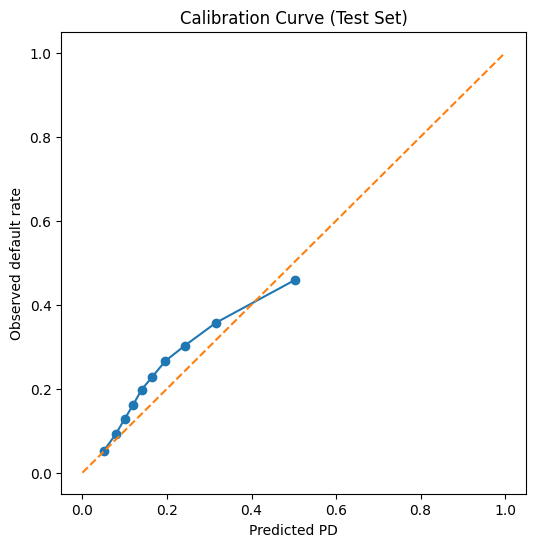

In [11]:
# Simple calibration curve plot
prob_true, prob_pred = calibration_curve(y_test, pd_test, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Predicted PD")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve (Test Set)")
plt.show()

### threshold view (optional - not a final policy)
This is just a quick view of what happens at a simple PD cut-off.

In [12]:
THRESH = 0.15  # illustrative only

y_hat = (pd_test >= THRESH).astype(int)

cm = confusion_matrix(y_test, y_hat)
cm

array([[224366, 178083],
       [ 32025,  84270]])

In [13]:
print(classification_report(y_test, y_hat, digits=3))


              precision    recall  f1-score   support

           0      0.875     0.558     0.681    402449
           1      0.321     0.725     0.445    116295

    accuracy                          0.595    518744
   macro avg      0.598     0.641     0.563    518744
weighted avg      0.751     0.595     0.628    518744



## 7) Model interpretability

In [14]:
# Extract feature names after preprocessing
ohe = clf.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + cat_feature_names

coefs = clf.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coefs
}).sort_values("coefficient", ascending=False)

coef_df.head(20), coef_df.tail(20)

(                                 feature  coefficient
 1                           int_rate_pct     0.091544
 0                            term_months     0.029291
 8                               open_acc     0.021036
 5                                    dti     0.019039
 7                         inq_last_6mths     0.018831
 126                  home_ownership_RENT     0.013816
 82                               grade_D     0.006163
 128  verification_status_Source Verified     0.005490
 81                               grade_C     0.005166
 9                                pub_rec     0.004594
 83                               grade_E     0.003325
 48                         addr_state_NY     0.003053
 6                            delinq_2yrs     0.002826
 99                          sub_grade_C4     0.001683
 102                         sub_grade_D2     0.001681
 76                purpose_small_business     0.001574
 67            purpose_debt_consolidation     0.001522
 23       

## 8) Write PD predictions back to SQLite
Store test-set PD scores in `loan_pd_predictions` to use them in later notebooks for approval thresholds and portfolio simulation.

In [18]:
pred_train = train_df[["row_id", "id", "issue_date"]].copy()
pred_train["pd_pred"] = pd_train
pred_train["set_name"] = "train"

pred_test = test_df[["row_id", "id", "issue_date"]].copy()
pred_test["pd_pred"] = pd_test
pred_test["set_name"] = "test"

pred_out = pd.concat([pred_train, pred_test], ignore_index=True)
pred_out["scored_at_utc"] = pd.Timestamp.utcnow().strftime("%Y-%m-%d %H:%M:%S")

pred_out.to_sql("loan_pd_predictions", con, if_exists="replace", index=False)

# Helpful indexes
con.execute("CREATE INDEX IF NOT EXISTS idx_pd_row_id ON loan_pd_predictions(row_id);")
con.execute("CREATE INDEX IF NOT EXISTS idx_pd_set_name ON loan_pd_predictions(set_name);")
con.commit()

con.execute("SELECT COUNT(*) FROM loan_pd_predictions;").fetchone()

(1345350,)

In [16]:
#Save artefacts
OUT_DIR = PROJECT_ROOT / "data" / "model"
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame([metrics]).to_csv(OUT_DIR / "model_metrics.csv", index=False)
coef_df.to_csv(OUT_DIR / "feature_coefficients.csv", index=False)

OUT_DIR

PosixPath('/home/jovyan/Home/notebooks/data/model')

In [19]:
import joblib
OUT_DIR = PROJECT_ROOT / "data" / "model"
joblib.dump(clf, OUT_DIR / "pd_logreg_pipeline.joblib")

['/home/jovyan/Home/notebooks/data/model/pd_logreg_pipeline.joblib']